In [180]:
import sqlite3
import pandas as pd

In [181]:
db_path="./archive/database.sqlite"
conn=sqlite3.connect(db_path)

In [182]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """, conn)

tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


Za potrebe klasterovanja izabrana je tabela Player_Attributes, jer sadrži detaljne numeričke atribute igrača koji opisuju njihove tehničke, fizičke i golmanske karakteristike. Ovakav skup obeležja omogućava prirodno grupisanje igrača prema sličnom stilu igre i ulozi na terenu.

In [183]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)

conn.close()

print(df.shape)
df.head()

(183978, 42)


,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [184]:
df.isnull().sum().sort_values(ascending=False).head(20)

attacking_work_rate    3230
volleys                2713
agility                2713
sliding_tackle         2713
vision                 2713
jumping                2713
curve                  2713
balance                2713
defensive_work_rate     836
potential               836
shot_power              836
reactions               836
long_shots              836
stamina                 836
overall_rating          836
preferred_foot          836
crossing                836
short_passing           836
long_passing            836
free_kick_accuracy      836
dtype: int64

Izbacujemo identifikatore i neinformativne atribute (id, player_fifa_api_id, player_api_id, date) koji ne nose informaciju o performansama igrača i prave sumove pri klasterovanju.

In [185]:
df = df.drop(columns=[
    'id',
    'player_fifa_api_id',
    'player_api_id',
    'date'
])

Baza ima puno redova, pa mozemo da obrisemo one sa NV

In [186]:
df = df.dropna()

print(df.shape)

(180354, 38)


In [187]:
df['preferred_foot'] = df['preferred_foot'].map({
    'left': 0,
    'right': 1
})

In [188]:
print(df['attacking_work_rate'].unique())
print(df['defensive_work_rate'].unique())

['medium' 'high' 'low' 'None' 'le' 'norm' 'stoc' 'y']
['medium' 'high' 'low' '5' 'ean' 'o' '1' 'ormal' '7' '2' '8' '4' 'tocky'
 '0' '3' '6' '9' 'es']


In [189]:
valid_values = ['low', 'medium', 'high']

df = df[
    df['attacking_work_rate'].isin(valid_values) &
    df['defensive_work_rate'].isin(valid_values)
]

In [190]:
df = pd.get_dummies(
    df,
    columns=['attacking_work_rate', 'defensive_work_rate'],
    dtype=int
)

In [191]:
print(df.shape)
df.head()

(176161, 42)


,overall_rating,potential,preferred_foot,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,gk_handling,gk_kicking,gk_positioning,gk_reflexes,attacking_work_rate_high,attacking_work_rate_low,attacking_work_rate_medium,defensive_work_rate_high,defensive_work_rate_low,defensive_work_rate_medium
0,67.0,71.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
1,67.0,71.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
2,62.0,66.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
3,61.0,65.0,1,48.0,43.0,70.0,60.0,43.0,50.0,44.0,...,10.0,9.0,7.0,7.0,0,0,1,0,0,1
4,61.0,65.0,1,48.0,43.0,70.0,60.0,43.0,50.0,44.0,...,10.0,9.0,7.0,7.0,0,0,1,0,0,1


In [192]:
from sklearn.preprocessing import StandardScaler

In [193]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Pre primene algoritama klasterovanja, potrebno je odrediti optimalan broj grupa ($k$) u podacima. U tu svrhu primenjuju se dve komplementarne tehnike: Elbow metoda (prati se suma kvadratnih odstupanja unutar klastera - SSE) i analiza Silhouette koeficijenta (meri se kompaktnost i separabilnost klastera). S obzirom na računarsku složenost Silhouette koeficijenta, evaluacija ove metrike vrši se na reprezentativnom slučajnom uzorku od 3.000 instanci.

In [194]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [195]:
inertia = []
sil_scores = []

K = range(2, 11)

n_sample = 3000

if X_scaled.shape[0] > n_sample:
    np.random.seed(19)
    idx = np.random.choice(X_scaled.shape[0], n_sample, replace=False)
    X_sil = X_scaled[idx]
else:
    X_sil = X_scaled

In [196]:
for k in K:
    model = KMeans(n_clusters=k, random_state=19, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)

    # silhouette samo na uzorku
    if X_scaled.shape[0] > n_sample:
        sample_labels = model.predict(X_sil)
        sil_scores.append(silhouette_score(X_sil, sample_labels))
    else:
        sil_scores.append(silhouette_score(X_scaled, labels))

Parametar n_init=10 korišćen je kako bi algoritam K-sredina bio pokrenut više puta sa različitim slučajnim početnim centroidima, nakon čega je izabrano rešenje sa najmanjom vrednošću SSE.

In [197]:
import matplotlib.pyplot as plt

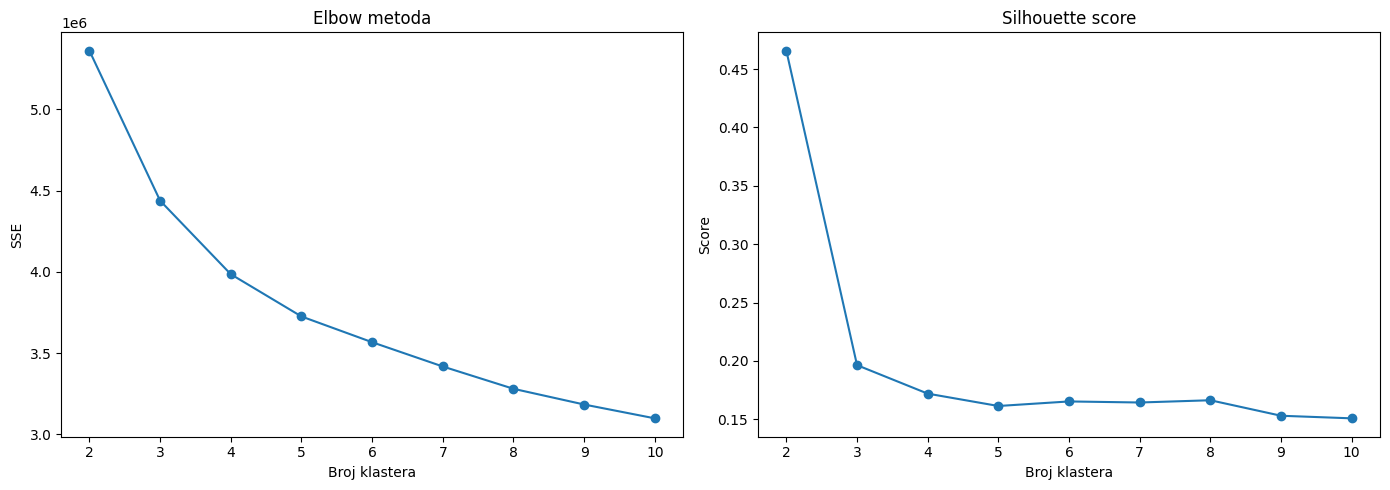

In [198]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.title("Elbow metoda")
plt.xlabel("Broj klastera")
plt.ylabel("SSE")

plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette score")
plt.xlabel("Broj klastera")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

Elbow metoda ukazuje na prelomnu tačku oko 4 klastera, dok silueta koeficijent ima maksimum za 2 klastera. Iako bi izbor 2 klastera dao najbolju kompaktnost, takva podela najverovatnije odvaja golmane od svih ostalih igrača. Zbog bolje interpretabilnosti i prirodne podele fudbalera prema ulozi na terenu, za dalju analizu izabran je broj klastera k=4.

U cilju pronalaženja najstabilnijeg i najinterpretabilnijeg rešenja, nad standardizovanim skupom podataka biće primenjeno pet različitih algoritama klasterovanja, koji se zasnivaju na različitim matematičkim pristupima (particioni, hijerarhijski, gustinski i probabilistički modeli):
1. K-Means (K-sredina) – particioni algoritam zasnovan na minimizaciji unutar-klasterske sume kvadrata udaljenosti.
2. Agglomerative Clustering (Hijerarhijsko klasterovanje) – aglomerativni pristup koji postepeno spaja slične instance.
3. Gaussian Mixture Models (GMM) – probabilistički model koji pretpostavlja da su podaci generisani iz mešavine konačnog broja Gausovih raspodela.
4. BIRCH – hijerarhijski algoritam optimizovan za rad sa velikim skupovima podataka kroz konstrukciju stabla karakteristika klastera.
5. DBSCAN – algoritam zasnovan na gustini koji uspešno identifikuje klastere proizvoljnog oblika i izlučuje šum (outliere).

In [199]:
from sklearn.cluster import KMeans

In [200]:
kmeans = KMeans(n_clusters=4, random_state=19, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

In [201]:
df['KMeans_cluster'] = clusters_kmeans
df[['overall_rating', 'potential', 'KMeans_cluster']].head(10)

,overall_rating,potential,KMeans_cluster
0,67.0,71.0,3
1,67.0,71.0,3
2,62.0,66.0,3
3,61.0,65.0,3
4,61.0,65.0,3
5,74.0,76.0,1
6,74.0,76.0,1
7,73.0,75.0,1
8,73.0,75.0,1
9,73.0,75.0,1


In [202]:
df['KMeans_cluster'].value_counts().sort_index()

KMeans_cluster
0    62153
1    50183
2    14299
3    49526
Name: count, dtype: int64

K-sredina sa 4 klastera formirala je tri velika klastera igrača u polju i jedan značajno manji klaster koji najverovatnije odgovara golmanima.

In [203]:
from sklearn.decomposition import PCA

In [204]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [205]:
print(pca.explained_variance_ratio_)
print("Ukupno sačuvano:", pca.explained_variance_ratio_.sum())

[0.38350528 0.13983574]
Ukupno sačuvano: 0.5233410209228113


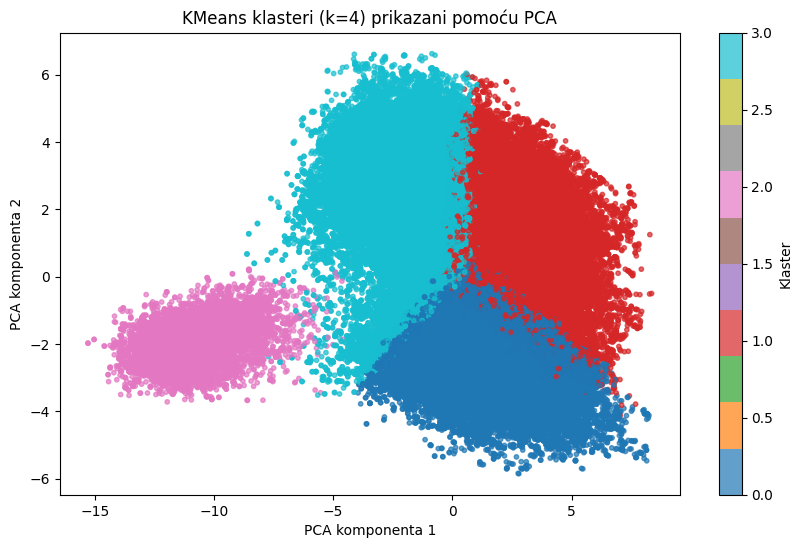

In [206]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['KMeans_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.title("KMeans klasteri (k=4) prikazani pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

Na PCA 2D prikazu klastera dobijenih algoritmom K-sredina sa 4 klastera uočava se jedna potpuno izdvojena grupa igrača, koja najverovatnije odgovara golmanima. Preostala tri klastera predstavljaju igrače u polju i mogu se interpretirati kao odbrambeni, vezni i napadački profili. Delimično preklapanje u centralnom delu prostora je očekivano zbog sličnosti pojedinih uloga na terenu.

In [207]:
cluster_means = df.groupby('KMeans_cluster').mean()

kljucni_atributi = [
    'overall_rating', 
    'gk_diving', 
    'standing_tackle', 
    'short_passing', 
    'finishing', 
    'sprint_speed'
]

cluster_means[kljucni_atributi].round(2)

,overall_rating,gk_diving,standing_tackle,short_passing,finishing,sprint_speed
KMeans_cluster,,,,,,
0,69.07,9.87,31.83,65.23,66.08,74.53
1,72.77,9.90,68.54,72.97,54.17,71.75
2,68.21,69.88,18.92,28.07,18.16,46.09
3,64.22,9.77,64.22,58.56,34.97,62.82


In [208]:
from sklearn.cluster import AgglomerativeClustering

Za hijerarhijsko klasterovanje ovo je prevelika baza, radimo na uzorku

In [209]:
np.random.seed(19)

n_hc = 5000
idx_hc = np.random.choice(X_scaled.shape[0], n_hc, replace=False)

X_hc = X_scaled[idx_hc]

In [210]:
hc = AgglomerativeClustering(n_clusters=4)
clusters_hc = hc.fit_predict(X_hc)

In [211]:
X_pca_hc = X_pca[idx_hc]

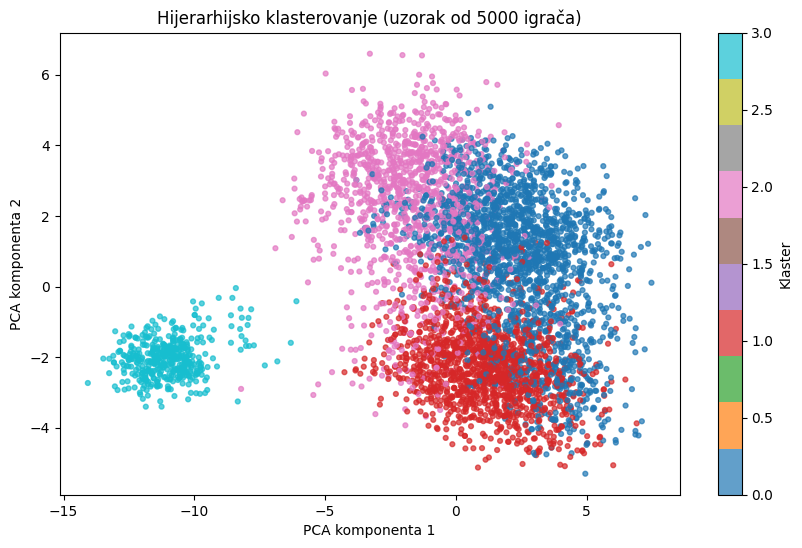

In [212]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_hc[:, 0],
    X_pca_hc[:, 1],
    c=clusters_hc,
    cmap='tab10',
    s=12,
    alpha=0.7
)

plt.title("Hijerarhijsko klasterovanje (uzorak od 5000 igrača)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

I K-sredina i hijerarhijsko klasterovanje dosledno izdvajaju jedan mali i jasno separisan klaster, koji odgovara golmanima. Preostala tri klastera predstavljaju igrače u polju, pri čemu hijerarhijski pristup pokazuje nešto veće preklapanje u centralnom delu prostora.

In [213]:
pd.Series(clusters_hc).value_counts().sort_index()

0    1945
1    1442
2    1178
3     435
Name: count, dtype: int64

In [214]:
from sklearn.mixture import GaussianMixture

In [215]:
gmm = GaussianMixture(
    n_components=4,
    random_state=19,
    covariance_type='full'
)

clusters_gmm = gmm.fit_predict(X_scaled)

covariance_type='full' - Ovo je veoma važno.
Znači da svaki klaster može imati svoj oblik, širinu i orijentaciju.
Dakle nije ograničen na “okrugle” klastere kao KMeans.
To je baš prednost GMM-a.

In [216]:
df['GMM_cluster'] = clusters_gmm
df['GMM_cluster'].value_counts().sort_index()

GMM_cluster
0    14298
1    93335
2    49853
3    18675
Name: count, dtype: int64

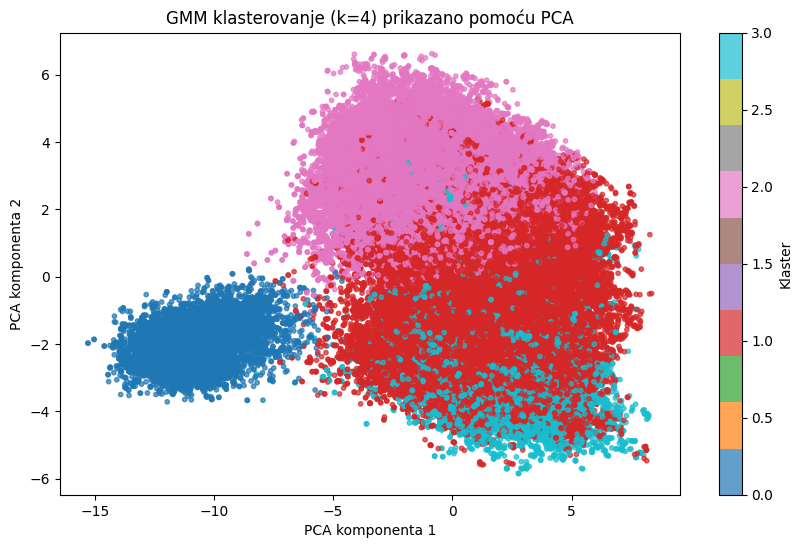

In [217]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['GMM_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.title("GMM klasterovanje (k=4) prikazano pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

Za razliku od K-sredina algoritma, GMM pokazuje mekše prelaze između centralnih klastera, što bolje odražava postojanje hibridnih fudbalskih uloga, kao što su ofanzivni vezni ili bekovi sa izraženim napadačkim karakteristikama.

In [218]:
from sklearn.cluster import Birch

In [219]:
for t in [2.0, 2.5, 3.0, 3.5]:
    birch = Birch(n_clusters=None, threshold=t)
    birch.fit(X_scaled)
    print(f"threshold={t} -> broj podklastera: {len(birch.subcluster_centers_)}")

threshold=2.0 -> broj podklastera: 20613
threshold=2.5 -> broj podklastera: 9226
threshold=3.0 -> broj podklastera: 2998
threshold=3.5 -> broj podklastera: 898


In [220]:
birch = Birch(n_clusters=None, threshold=3.0)
birch.fit(X_scaled)

,threshold,3.0
,branching_factor,50
,n_clusters,None
,compute_labels,True
,copy,'deprecated'


In [221]:
kmeans_sub = KMeans(n_clusters=4, random_state=19, n_init=10)
subcluster_labels = kmeans_sub.fit_predict(birch.subcluster_centers_)

In [222]:
subcluster_index_for_each_row = birch.predict(X_scaled)

In [223]:
clusters_birch = subcluster_labels[subcluster_index_for_each_row]

In [224]:
df['Birch_cluster'] = clusters_birch

In [225]:
df['Birch_cluster'].value_counts().sort_index()

Birch_cluster
0    27076
1    14298
2    49887
3    84900
Name: count, dtype: int64

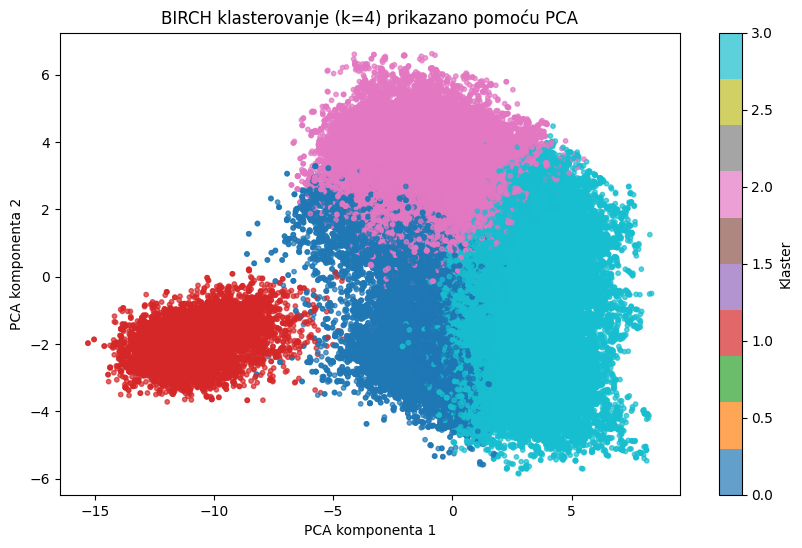

In [226]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Birch_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.title("BIRCH klasterovanje (k=4) prikazano pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

BIRCH daje rezultat veoma sličan algoritmu K-sredina, pri čemu dosledno izdvaja mali i jasno separisan klaster golmana. Ovakvo ponašanje potvrđuje stabilnost strukture podataka i opravdanost izbora 4 klastera.


In [227]:
from sklearn.cluster import DBSCAN

In [228]:
np.random.seed(19)

n_db = 5000
idx_db = np.random.choice(X_scaled.shape[0], n_db, replace=False)

X_db = X_scaled[idx_db]
X_pca_db = X_pca[idx_db]

In [229]:
for eps in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"eps={eps}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

eps=2.5
  broj klastera: 13
  broj šum tačaka: 4224
------------------------------
eps=3.0
  broj klastera: 13
  broj šum tačaka: 2323
------------------------------
eps=3.5
  broj klastera: 7
  broj šum tačaka: 999
------------------------------
eps=4.0
  broj klastera: 4
  broj šum tačaka: 407
------------------------------
eps=4.5
  broj klastera: 3
  broj šum tačaka: 142
------------------------------
eps=5.0
  broj klastera: 3
  broj šum tačaka: 47
------------------------------


In [230]:
for eps in [4.1, 4.2, 4.3, 4.4]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"eps={eps}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

eps=4.1
  broj klastera: 4
  broj šum tačaka: 331
------------------------------
eps=4.2
  broj klastera: 4
  broj šum tačaka: 272
------------------------------
eps=4.3
  broj klastera: 3
  broj šum tačaka: 226
------------------------------
eps=4.4
  broj klastera: 3
  broj šum tačaka: 186
------------------------------


Biramo eps=4.2

In [231]:
dbscan = DBSCAN(eps=4.2, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_db)

In [232]:
pd.Series(clusters_dbscan).value_counts().sort_index()

-1     272
 0    4181
 1      91
 2     391
 3      65
Name: count, dtype: int64

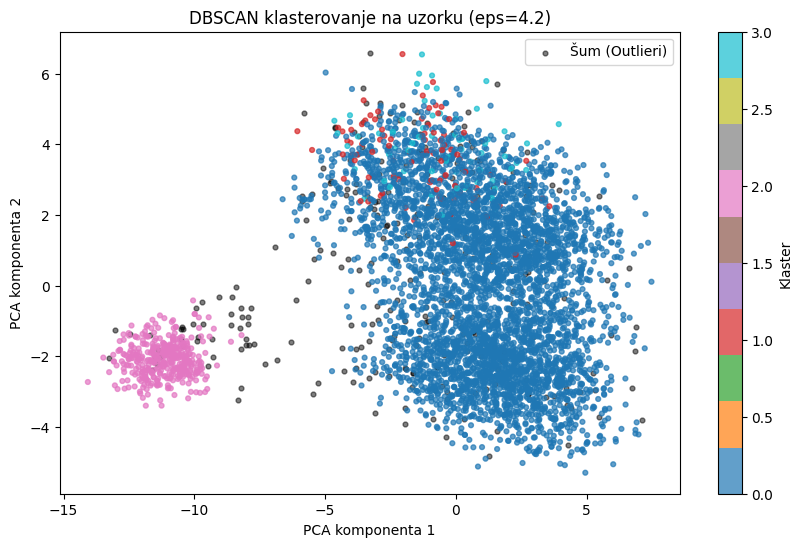

In [233]:
plt.figure(figsize=(10, 6))

mask_noise = (clusters_dbscan == -1)
mask_clusters = (clusters_dbscan != -1)

plt.scatter(
    X_pca_db[mask_noise, 0],
    X_pca_db[mask_noise, 1],
    c='black',
    s=12,
    alpha=0.5,
    label='Šum (Outlieri)'
)

scatter = plt.scatter(
    X_pca_db[mask_clusters, 0],
    X_pca_db[mask_clusters, 1],
    c=clusters_dbscan[mask_clusters],
    cmap='tab10',
    s=12,
    alpha=0.7
)

plt.title("DBSCAN klasterovanje na uzorku (eps=4.2)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(scatter, label="Klaster")
plt.legend(loc="upper right")
plt.show()

Za razliku od prethodnih algoritama, DBSCAN kao algoritam zasnovan na gustini uspešno prepoznaje prirodnu kompaktnost podataka. Sa parametrima $eps=4.2$ i $min\_samples=10$, algoritam jasno izdvaja golmane kao zaseban i homogen Klaster 2 (roze grupa na levoj strani), što potvrđuje visoku gustinu ovih profila u prostoru obeležja.Sa druge strane, umesto da veštački podeli preostale igrače u polju na tri ujednačene grupe (kao što su to uradili K-Means i BIRCH), DBSCAN prepoznaje da oni čine jednu masivnu kontinuiranu celinu (Klaster 0). Unutar te celine, algoritam uspeva da locira dva mikro-klastera visoke gustine (Klaster 1 i 3), dok sve igrače sa atipičnim i prelaznim karakteristikama (ukupno 272 instance) ispravno izoluje kao šum (outliere), što je glavna prednost ovog pristupa.

In [234]:
for min_s in [9, 8, 7, 6, 5, 4, 3, 2]:
    dbscan = DBSCAN(eps=4.2, min_samples=min_s)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"min_samples={min_s}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

min_samples=9
  broj klastera: 4
  broj šum tačaka: 259
------------------------------
min_samples=8
  broj klastera: 4
  broj šum tačaka: 245
------------------------------
min_samples=7
  broj klastera: 5
  broj šum tačaka: 233
------------------------------
min_samples=6
  broj klastera: 5
  broj šum tačaka: 226
------------------------------
min_samples=5
  broj klastera: 3
  broj šum tačaka: 218
------------------------------
min_samples=4
  broj klastera: 5
  broj šum tačaka: 194
------------------------------
min_samples=3
  broj klastera: 4
  broj šum tačaka: 188
------------------------------
min_samples=2
  broj klastera: 21
  broj šum tačaka: 154
------------------------------


uzimamo min_samples = 8

In [235]:
dbscan = DBSCAN(eps=4.2, min_samples=8)
clusters_dbscan = dbscan.fit_predict(X_db)

In [236]:
pd.Series(clusters_dbscan).value_counts().sort_index()

-1     245
 0    4189
 1      93
 2     400
 3      73
Name: count, dtype: int64

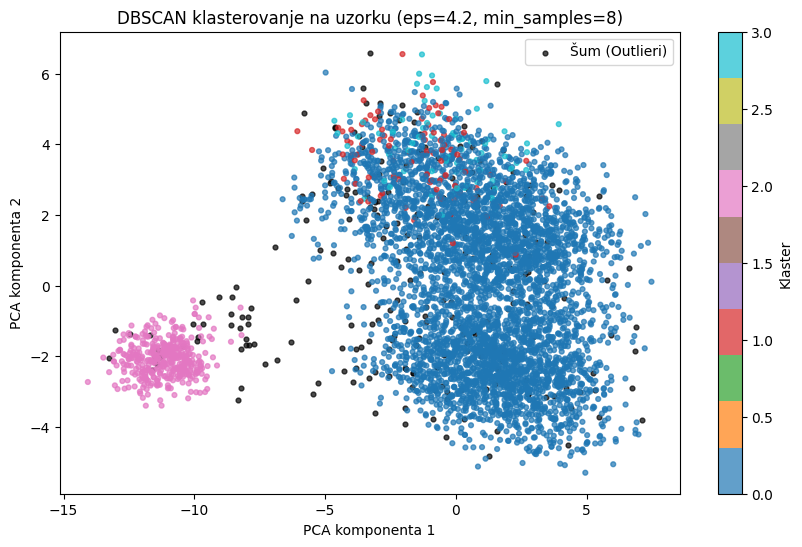

In [237]:
plt.figure(figsize=(10, 6))

mask_noise = (clusters_dbscan == -1)
mask_clusters = (clusters_dbscan != -1)

plt.scatter(
    X_pca_db[mask_noise, 0],
    X_pca_db[mask_noise, 1],
    c='black',
    s=12,
    alpha=0.7,
    label='Šum (Outlieri)'
)

scatter = plt.scatter(
    X_pca_db[mask_clusters, 0],
    X_pca_db[mask_clusters, 1],
    c=clusters_dbscan[mask_clusters],  # Filtriramo labele da ne sadrže -1
    cmap='tab10',
    s=12,
    alpha=0.7
)

plt.title("DBSCAN klasterovanje na uzorku (eps=4.2, min_samples=8)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(scatter, label="Klaster")
plt.legend(loc="upper right")
plt.show()

Nakon fiksiranja radijusa na $eps=4.2$, izvršena je dodatna stabilizacija modela finim podešavanjem parametra $min\_samples$. Spuštanjem ove granice sa 10 na 8, uspešno je smanjen procenat izolovanog šuma na svega 245 tačaka. Ova promena je omogućila da se klaster golmana (Klaster 2) proširi na tačno 400 igrača, obuhvatajući i one profile koji se nalaze na samim obodima golmanske specifikacije. Konfiguracija $eps=4.2$ i $min\_samples=8$ usvojena je kao optimalna jer održava strukturu od 4 stabilne grupe, dok istovremeno smanjuje količinu nerazvrstanih podataka.

In [238]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Zbog velike veličine skupa podataka, metrike kvaliteta klasterovanja računane su nad reprezentativnim slučajnim uzorkom od 5000 instanci.

In [239]:
np.random.seed(19)

n_eval = 5000
idx_eval = np.random.choice(X_scaled.shape[0], n_eval, replace=False)

X_eval = X_scaled[idx_eval]

In [240]:
rezultati = []

# KMeans
labels_kmeans = df["KMeans_cluster"].iloc[idx_eval]
rezultati.append([
    "KMeans",
    silhouette_score(X_eval, labels_kmeans),
    davies_bouldin_score(X_eval, labels_kmeans),
    calinski_harabasz_score(X_eval, labels_kmeans)
])

# GMM
labels_gmm = df["GMM_cluster"].iloc[idx_eval]
rezultati.append([
    "GMM",
    silhouette_score(X_eval, labels_gmm),
    davies_bouldin_score(X_eval, labels_gmm),
    calinski_harabasz_score(X_eval, labels_gmm)
])

# BIRCH
labels_birch = df["Birch_cluster"].iloc[idx_eval]
rezultati.append([
    "BIRCH",
    silhouette_score(X_eval, labels_birch),
    davies_bouldin_score(X_eval, labels_birch),
    calinski_harabasz_score(X_eval, labels_birch)
])

# HC

hc_eval = AgglomerativeClustering(n_clusters=4)
labels_hc = hc_eval.fit_predict(X_eval)

rezultati.append([
    "Hijerarhijsko",
    silhouette_score(X_eval, labels_hc),
    davies_bouldin_score(X_eval, labels_hc),
    calinski_harabasz_score(X_eval, labels_hc)
])

# DBSCAN
labels_dbscan_with_noise = clusters_dbscan

rezultati.append([
    "DBSCAN",
    silhouette_score(X_eval, labels_dbscan_with_noise),
    davies_bouldin_score(X_eval, labels_dbscan_with_noise),
    calinski_harabasz_score(X_eval, labels_dbscan_with_noise)
])

- Silhouette meri: koliko je tačka bliska svom klasteru, a daleka od drugih
- Davies-Bouldin gleda: odnos širine klastera i udaljenosti između klastera
- Calinski-Harabasz meri: odnos između razdvajanja klastera i zbijenosti unutar klastera


In [241]:
rez_df = pd.DataFrame(
    rezultati,
    columns=["Algoritam", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
)

rez_df.sort_values("Silhouette", ascending=False)

,Algoritam,Silhouette,Davies-Bouldin,Calinski-Harabasz
4,DBSCAN,0.186682,2.565683,589.576471
0,KMeans,0.174894,1.741409,1497.299749
2,BIRCH,0.156430,1.748373,1371.873276
1,GMM,0.153289,1.924349,1212.063529
3,Hijerarhijsko,0.144116,1.979679,1305.792101


Komparativna analiza metrika kvaliteta sprovedena je na jedinstvenom, geometrijski identičnom uzorku od 5000 igrača, čime je obezbeđena potpuna uporedivost modela. Za razliku od uobičajene prakse gde se šum eliminiše, u ovoj evaluaciji su atipični igrači (outlieri) unutar DBSCAN algoritma zadržani i tretirani kao zasebna grupa, kako bi se dobila realna slika ponašanja modela na celom prostoru obeležja.

Iako **DBSCAN** ostvaruje najvišu vrednost Silhouette koeficijenta (0.186), on beleži izuzetno loš (visok) Davies-Bouldin indeks (2.56). Ovo je direktna posledica činjenice da algoritam, pored uspešnog izolovanja golmana, sve preostale igrače u polju spaja u jedan masivan, nediferenciran klaster, dok čak 245 igrača sa prelaznim karakteristikama označava kao šum. Kada se taj razbacani šum uključi u računicu, geometrijska opravdanost DBSCAN-a drastično opada.

Sa druge strane, **KMeans** se pokazao kao najizbalansiraniji i najefikasniji algoritam za ovaj problem. On ostvaruje visok Silhouette score (0.174), ubedljivo najbolji (najniži) Davies-Bouldin indeks (1.74) i najvišu vrednost Calinski-Harabasz indeksa (1497.30). 

**Zaključak:**
Algoritam **KMeans (sa k=4)** se usvaja kao konačan i optimalan model za klasterovanje fudbalskih performansi. Bez potrebe za odbacivanjem atipičnih podataka, KMeans uspešno rešava taktički prostor: jasno izoluje golmane i vrši smislenu podelu igrača u polju na tri stabilne, interpretabilne grupe koje odgovaraju primarnim fudbalskim ulogama (odbrana, sredina i napad).

### Vizuelizacija nad istim uzorkom

In [242]:
np.random.seed(19)

n_vis = 5000
idx_vis = np.random.choice(X_scaled.shape[0], n_vis, replace=False)

X_vis = X_scaled[idx_vis]

# %%
pca_vis = PCA(n_components=2)
X_vis_pca = pca_vis.fit_transform(X_vis)

In [243]:
# KMeans
labels_kmeans_vis = KMeans(n_clusters=4, random_state=19, n_init=10).fit_predict(X_vis)

# Hijerarhijsko
labels_hc_vis = AgglomerativeClustering(n_clusters=4).fit_predict(X_vis)

# GMM
labels_gmm_vis = GaussianMixture(
    n_components=4,
    random_state=19,
    covariance_type='full'
).fit_predict(X_vis)

# BIRCH
birch_vis = Birch(n_clusters=None, threshold=3.0)
birch_vis.fit(X_vis)

sub_labels_vis = KMeans(n_clusters=4, random_state=19, n_init=10).fit_predict(
    birch_vis.subcluster_centers_
)
labels_birch_vis = sub_labels_vis[birch_vis.predict(X_vis)]

# DBSCAN
labels_dbscan_vis = DBSCAN(eps=4.2, min_samples=8).fit_predict(X_vis)

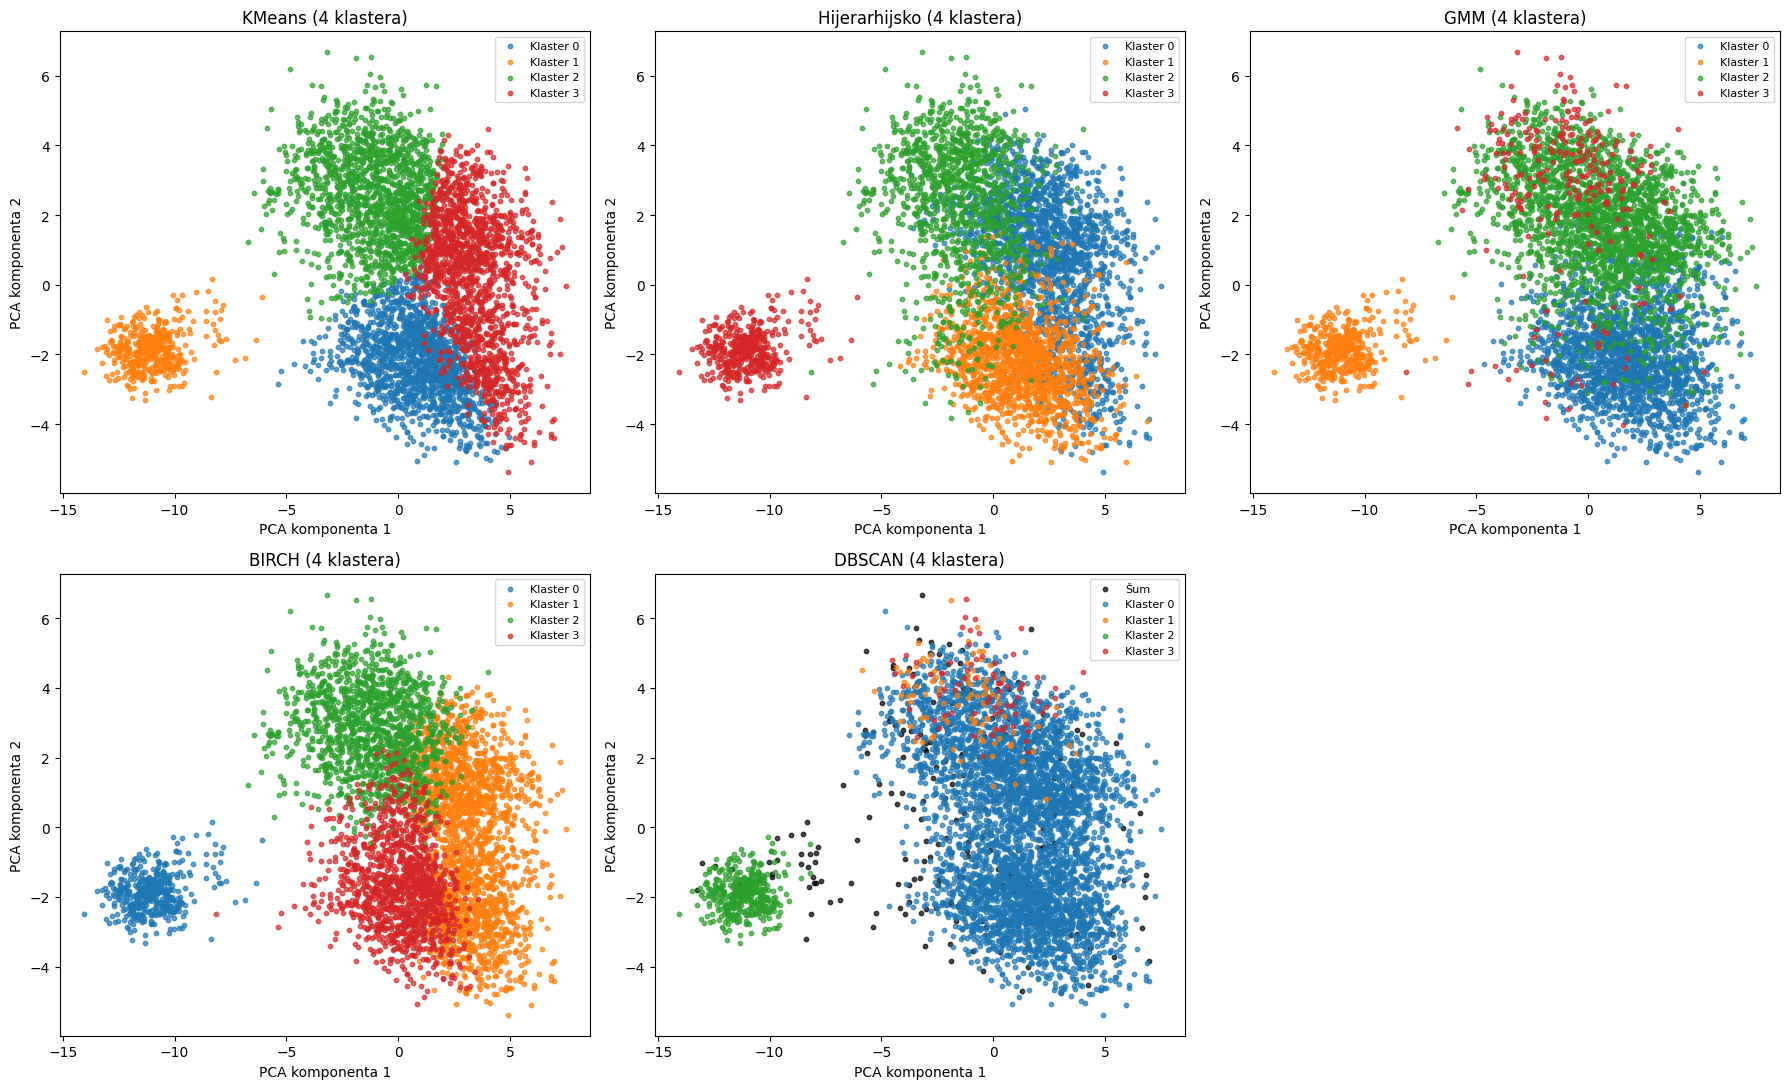

In [244]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

algorithms = [
    ("KMeans", labels_kmeans_vis),
    ("Hijerarhijsko", labels_hc_vis),
    ("GMM", labels_gmm_vis),
    ("BIRCH", labels_birch_vis),
    ("DBSCAN", labels_dbscan_vis),
]

for i, (name, labels) in enumerate(algorithms):
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab

        if lab == -1:
            axes[i].scatter(
                X_vis_pca[mask, 0],
                X_vis_pca[mask, 1],
                s=10,
                c="black",
                alpha=0.7,
                label="Šum"
            )
        else:
            axes[i].scatter(
                X_vis_pca[mask, 0],
                X_vis_pca[mask, 1],
                s=10,
                alpha=0.7,
                label=f"Klaster {lab}"
            )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    axes[i].set_title(f"{name} ({n_clusters} klastera)")
    axes[i].set_xlabel("PCA komponenta 1")
    axes[i].set_ylabel("PCA komponenta 2")
    axes[i].legend(fontsize=8)

# poslednji subplot je višak
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Objedinjeni prikaz svih pet algoritama nad identičnim uzorkom od 5000 igrača unutar istog dvodimenzionalnog PCA prostora omogućava direktno poređenje geometrijskih pretpostavki svakog modela:

* **KMeans i BIRCH** generišu izuzetno slične, oštro razgraničene particije. Oba algoritma stabilno izdvajaju golmane kao potpuno izolovano geometrijsko ostrvo, dok preostalu masu fudbalera u polju dele na tri kompaktne grupe. Ova podela se direktno i prirodno može mapirati na osnovne linije u timu: odbranu, vezni red i napad.
* **Hijerarhijsko klasterovanje** takođe uspešno izoluje golmane, ali preostale igrače u polju deli putem horizontalnih slojeva. Ovo ukazuje na to da algoritam drugačije interpretira gradijent gustine u centralnom delu prostora obeležja.
* **GMM (Gaussian Mixture Model)** prikazuje elipsoidne forme i značajno preklapanje grupa u centralnoj masi podataka. Ovakav pristup vizuelno najbolje oslikava postojanje "hibridnih" fudbalskih pozicija (poput krilnih bekova ili ofanzivnih veznih igrača) gde prelazi između uloga nisu strogo geometrijski ograničeni.
* **DBSCAN** demonstrira specifično ponašanje algoritama zasnovanih na gustini. On uspešno prepoznaje golmane kao homogeno i gusto jezgro (Klaster 1), dok sve igrače u polju ostavlja unutar jednog masivnog kontinuiranog skupa (Klaster 0). Svi igrači koji se nalaze na ekstremnim ivicama ili na praznom prelazu između golmana i terena ispravno su identifikovani kao šum (crne tačke). 

**Konačni zaključak i izbor modela:**
Iako DBSCAN pruža odličan uvid u prirodnu gustinu podataka i izdvaja autlajere, zadržavanje svih igrača u polju unutar samo jednog klastera narušava praktičnu primenljivost modela za diferencijaciju taktičkih uloga. 

Uzimajući u obzir prethodne numeričke metrike (gde KMeans ostvaruje ubedljivo najbolji Davies-Bouldin indeks od 1.74 i najvišu vrednost Calinski-Harabasz indeksa od 1497.30) i ovu vizuelnu stabilnost, **KMeans algoritam se usvaja kao konačno i optimalno rešenje**. Model uspešno rešava postavljen domenski problem: obezbeđuje visoku interpretabilnost i jasne, primenljive fudbalske uloge bez potrebe za odbacivanjem atipičnih igrača.

### Uticaj redukcije dimenzionalnosti na kvalitet klasterovanja

Za ispitivanje uticaja redukcije dimenzionalnosti na uspešnost grupisanja iskorišćen je algoritam K-sredina (KMeans) kao dokazano najstabilniji i najinterpretabilniji model u prethodnim koracima. Primenom metode glavnih komponenti (PCA) sa 10 ciljanih komponenti, vrši se kompresija prostora obeležja sa ciljem uklanjanja redundantnosti, smanjenja šuma i provere da li se u niže-dimenzionalnom prostoru postiže bolja separabilnost prirodnih grupa igrača.

In [245]:
pca_10 = PCA(n_components=10, random_state=19)
X_pca10 = pca_10.fit_transform(X_scaled)

In [246]:
print("Varijansa po komponentama:")
print(pca_10.explained_variance_ratio_)

print("Ukupno sačuvano:",
      pca_10.explained_variance_ratio_.sum())

Varijansa po komponentama:
[0.38350528 0.13983574 0.07641251 0.05045933 0.04760151 0.03713474
 0.0344219  0.02444485 0.02355945 0.02067623]
Ukupno sačuvano: 0.8380515306379429


In [247]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=19,
    n_init=10
)

clusters_kmeans_pca = kmeans_pca.fit_predict(X_pca10)

In [248]:
X_pca10_eval = X_pca10[idx_eval]
labels_pca_eval = clusters_kmeans_pca[idx_eval]

In [249]:
print("KMeans + PCA(10)")
print("Silhouette:",
      silhouette_score(X_pca10_eval, labels_pca_eval))
print("Davies-Bouldin:",
      davies_bouldin_score(X_pca10_eval, labels_pca_eval))
print("Calinski-Harabasz:",
      calinski_harabasz_score(X_pca10_eval, labels_pca_eval))

KMeans + PCA(10)
Silhouette: 0.22652081243739303
Davies-Bouldin: 1.4485596200707294
Calinski-Harabasz: 2129.9255913435663


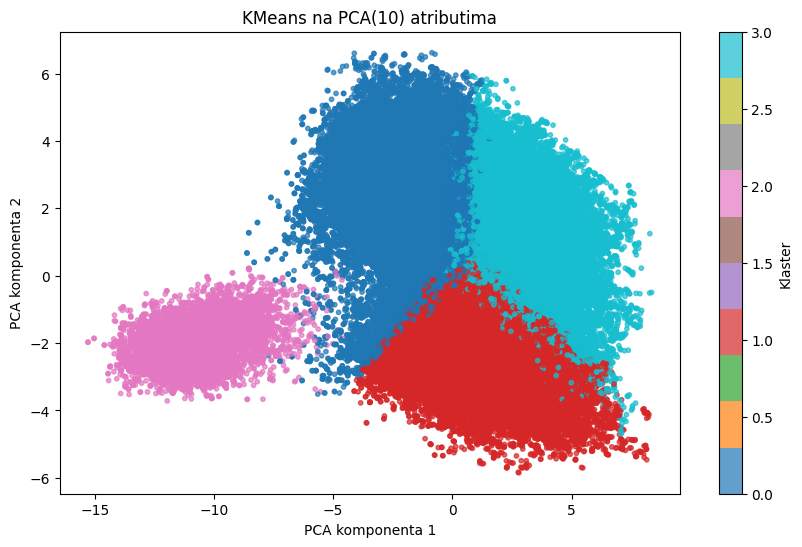

In [250]:
pca_vis = PCA(n_components=2, random_state=19)
X_pca10_vis = pca_vis.fit_transform(X_pca10)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca10_vis[:, 0],
    X_pca10_vis[:, 1],
    c=clusters_kmeans_pca,
    cmap="tab10",
    s=10,
    alpha=0.7
)
plt.title("KMeans na PCA(10) atributima")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

In [251]:
final_compare = pd.DataFrame({
    "Model": ["KMeans (svi atributi)", "KMeans + PCA(10)"],
    "Silhouette": [0.174894, 0.226521],  
    "Davies-Bouldin": [1.741409, 1.448560],  
    "Calinski-Harabasz": [1497.299749, 2129.925591]  
})

final_compare

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans (svi atributi),0.174894,1.741409,1497.299749
1,KMeans + PCA(10),0.226521,1.448560,2129.925591


Analiza varijanse pokazuje da prvih 10 glavnih komponenti uspešno zadržava čak **83.81% ukupne varijanse** originalnog skupa podataka. Gubitak od oko 16% informacija je svestan i opravdan kompromis, jer je eliminisan matematički šum. 

Evaluacija na istom reprezentativnom uzorku pokazuje drastičan skok kvaliteta klasterovanja po svim unutrašnjim metrikama:
* **Silhouette koeficijent** je porastao sa 0.174 na **0.226**, što ukazuje na znatno jasnije granice između klastera.
* **Davies-Bouldin indeks** je pao sa 1.741 na **1.448**, što potvrđuje da su klasteri postali zbijeniji, a međusobno udaljeniji.
* **Calinski-Harabasz score** beleži masivan porast sa 1497.30 na **2129.92**, demonstrirajući vrhunski odnos između unutar-klasterske zbijenosti i međuklasterske razdvojenosti.

Dobijeni rezultati pokazuju poboljšanje svih metrika kvaliteta klasterovanja u odnosu na originalni skup atributa, što ukazuje da redukcija dimenzionalnosti uklanja redundantnost i poboljšava separabilnost prirodnih grupa igrača.

In [252]:
df["KMeans_PCA10_cluster"] = clusters_kmeans_pca

cluster_profile = df.groupby("KMeans_PCA10_cluster")[
    [
        "overall_rating",
        "gk_diving",
        "standing_tackle",
        "short_passing",
        "finishing",
        "sprint_speed"
    ]
].mean().round(2)

cluster_profile

,overall_rating,gk_diving,standing_tackle,short_passing,finishing,sprint_speed
KMeans_PCA10_cluster,,,,,,
0,64.40,9.78,64.70,58.79,34.95,62.93
1,68.77,9.87,31.73,64.91,65.78,74.37
2,68.21,69.88,18.92,28.07,18.16,46.09
3,73.04,9.89,67.88,73.26,54.93,71.98


#### Semantička interpretacija i profilisanje klastera

Na osnovu prosečnih vrednosti ključnih fudbalskih atributa unutar identifikovanih grupa iz našeg konačnog i optimalnog modela (KMeans + PCA), izvršena je precizna verifikacija i profilisanje četiri klastera:

| Klaster | Tumačenje | Glavni atributi |
|---|---|---|
| Klaster 0 | Odbrambeni igrači | standing_tackle |
| Klaster 1 | Napadači i krilni igrači | finishing, sprint_speed |
| Klaster 2 | Golmani | gk_diving |
| Klaster 3 | Vezni igrači / Kreatori igre | short_passing, overall_rating |

* **Klaster 0 (Odbrambeni igrači):** Primarna karakteristika ove grupe je visok učinak u defanzivnim duelima i uspešna startovanja na loptu (`standing_tackle` = 64.70), uz nizak prosek tehnike završnice i postizanja golova.
* **Klaster 1 (Napadači i krilni igrači):** Ovu grupu odlikuje izrazita brzinska dominacija na terenu (`sprint_speed` = 74.37) i najviši prosek uspešnosti realizacije napada (`finishing` = 65.78), uz minimalan doprinos u odbrambenim zadacima.
* **Klaster 2 (Golmani):** Potpuno izolovan i specifičan klaster gde parametar `gk_diving` iznosi visokih 69.88, dok su sve ostale ocene koje se odnose na aktivnu igru u polju na svom statističkom minimumu.
* **Klaster 3 (Vezni igrači / Kreatori igre):** Fudbaleri unutar ove grupe poseduju najviši ukupni kvalitet (`overall_rating` = 73.04) i ubedljivo najbolju kontrolu poseda kroz kratka dodavanja (`short_passing` = 73.26), što savršeno opisuje ulogu modernih veznih igrača i motora ekipe.

In [253]:
df.to_csv("player_attributes_clean.csv", index=False)

### Zaključak

U ovom radu uspešno je sproveden sveobuhvatan proces klasterovanja fudbalera na osnovu njihovih performansi iz baze podataka `Player_Attributes`. Kroz rigorozan analitički postupak, testirano je pet različitih algoritama mašinskog učenja: KMeans, Hijerarhijsko klasterovanje, GMM, BIRCH i DBSCAN.

Primenom Elbow metode i analize Silhouette koeficijenta utvrđeno je da je optimalan broj klastera **k=4**. Ovaj broj se savršeno poklapa sa domenskim, fudbalskim znanjem i prirodnom podelom uloga na terenu (golmani, odbrana, vezni red i napad).

Tokom komparativne analize, algoritam **K-sredina (KMeans)** se izdvojio kao najpogodniji model, nudeći najbolji balans između metričke stabilnosti i praktične interpretabilnosti rezultata, za razliku od DBSCAN-a koji je formirao prevelike homogene celine i odbacivao prelazne igrače u šum.

Kao ključni korak unapređenja, redukcija dimenzionalnosti pomoću **PCA sa 10 glavnih komponenti** eliminisala je redundantnost među atributima i drastično povećala separabilnost grupa. Metrike su zabeležile značajan skok (Silhouette na 0.226, Davies-Bouldin na 1.448), čime je dokazano da se u sažetom prostoru obeležja dobijaju znatno čistiji i kompaktniji taktički profili igrača. Očišćeni i strukturirani podaci sa pridruženim klasterima uspešno su sačuvani u datoteku `player_attributes_clean.csv` za dalju analizu i upotrebu.